In [46]:
import pandas as pd

In [47]:
!ls ../CSVs/Fondeo2/

'25mar25_Whistle FONDEO2_verificado.csv'   Fondeo2_Whistles_Standardized.csv


In [48]:
# take list of csv files in ../CSVs/ and read them into a dictionary of dataframes
csv_files = !ls ../CSVs/Fondeo2/

In [49]:
VALIDATION = "Fondeo2"

In [50]:
# df = pd.DataFrame()

# # Load file
# for file in csv_files:
#     df = pd.concat([df, pd.read_csv(f'../CSVs/{VALIDATION}/{file}')]) 

In [51]:
df = pd.read_csv(f'../CSVs/{VALIDATION}/25mar25_Whistle FONDEO2_verificado.csv')

In [52]:
df

,Idx,Specie,File,Validation,Suggested Specie,Comment
0,1,Whistle,channelA_2024-05-27_21-43-19_48kHz_286_293_0.5...,1.0,NaN,NaN
1,2,Whistle,channelA_2024-05-27_21-48-19_48kHz_0_5_0.98.WAV,1.0,NaN,NaN
2,3,Whistle,channelA_2024-05-27_21-48-19_48kHz_103_110_0.9...,1.0,NaN,NaN
3,4,Whistle,channelA_2024-05-27_21-48-19_48kHz_106_113_0.9...,1.0,NaN,NaN
4,5,Whistle,channelA_2024-05-27_21-48-19_48kHz_109_116_1.0...,1.0,NaN,NaN
...,...,...,...,...,...,...
150,151,Whistle,channelA_2024-06-12_16-00-33_48kHz_106_113_0.6...,0.0,Ferry,Clicks de What y ferry
151,152,Whistle,channelA_2024-06-12_16-15-33_48kHz_25_32_0.58.WAV,0.0,Ferry,Clicks de What y ferry
152,153,Whistle,channelA_2024-06-12_16-15-33_48kHz_34_41_0.61.WAV,0.0,Ferry,Clicks de What y ferry
153,154,Whistle,channelA_2024-06-12_16-15-33_48kHz_40_47_0.61.WAV,0.0,Ferry,Clicks de What y ferry


In [53]:
df = df[df['Validation'] != -100]
# df = df[df['Validation'] != -1]
# df = df[df['Validation'] != -2]

In [54]:
# reset index
df = df.reset_index(drop=True)

In [55]:
# Change validation values to Correct if 1, Other specie if 0, Unknown if -2, Bird if 2
df['Validation_Val'] = df['Validation'].map({1: 'Correct', 0: 'Other', -2: 'Unknown', 2: 'Cetacean', -1: 'Incorrect'})

<Figure size 1200x800 with 0 Axes>

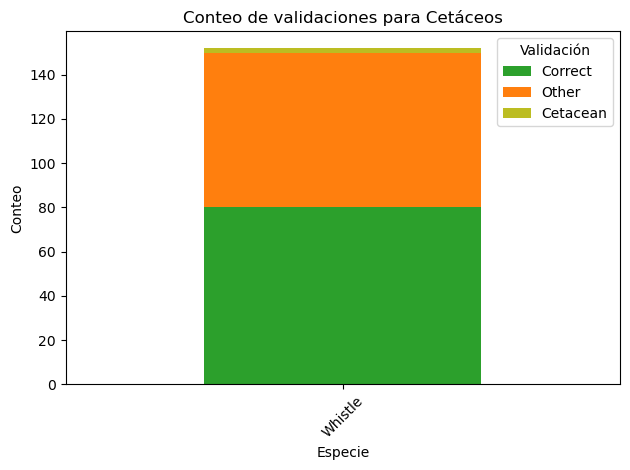

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your DataFrame


# Green for Correct, Orange for Bird, Red for Other specie, Blue for Unknown
colors = {'Correct': 'C2', 'Cetacean': 'C8', 'Other': 'C1', 'Unknown': 'C0', "Incorrect:": "C3"}

# Group by 'Specie' and 'Validation' and count occurrences
grouped = df.groupby(['Specie', 'Validation_Val']).size().unstack(fill_value=0)

# Ensure the columns are in the correct order
grouped = grouped[['Correct', 'Other', 'Cetacean']]

# Plotting
plt.figure(figsize=(12, 8))
grouped.plot(kind='bar', stacked=True, color=[colors[val] for val in grouped.columns])
plt.title('Conteo de validaciones para Cetáceos')
plt.xlabel('Especie')
plt.ylabel('Conteo')
plt.legend(title='Validación')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [57]:
df["Suggested Specie"].unique()

array([nan, 'Motor boat', 'What?', 'Ferry', 'Bird', 'Ambiental',
       'Respiracion', 'Whistle'], dtype=object)

In [58]:
# If validation is correct, set the suggested specie is the same as the specie
df.loc[df['Validation'] == 1, 'Suggested Specie'] = df['Specie']
# if Validation is -2, set Suggested Specie to Cetacean
df.loc[df['Validation'] == 2, 'Suggested Specie'] = 'Cetacean'

In [59]:
# # Drop rows where Validation is Unknown and Bird in df
# print(len(df))

# df = df[df.Validation != 'Unknown']
# df = df[df.Validation != 'Bird']

# print(len(df))

In [60]:
# Reset the index to ensure unique labels
df = df.reset_index(drop=True)

df["SegmentFile"] = df["File"]
df["StartSecond"] = df["File"].str.split("_").str.get(-3)
df["EndSecond"] = df["File"].str.split("_").str.get(-2)
df["ConfidenceScore"] = df["File"].str.replace(".WAV","").str.split("_").str.get(-1)
# File = File split but last 4 elements separated by _
df["File"] = df["File"].str.split('_').str[:-4].str.join('_') + ".WAV"
df

,Idx,Specie,File,Validation,Suggested Specie,Comment,Validation_Val,SegmentFile,StartSecond,EndSecond,ConfidenceScore
0,1,Whistle,channelA_2024-05-27_21-43-19.WAV,1.0,Whistle,NaN,Correct,channelA_2024-05-27_21-43-19_48kHz_286_293_0.5...,286,293,0.56
1,2,Whistle,channelA_2024-05-27_21-48-19.WAV,1.0,Whistle,NaN,Correct,channelA_2024-05-27_21-48-19_48kHz_0_5_0.98.WAV,0,5,0.98
2,3,Whistle,channelA_2024-05-27_21-48-19.WAV,1.0,Whistle,NaN,Correct,channelA_2024-05-27_21-48-19_48kHz_103_110_0.9...,103,110,0.91
3,4,Whistle,channelA_2024-05-27_21-48-19.WAV,1.0,Whistle,NaN,Correct,channelA_2024-05-27_21-48-19_48kHz_106_113_0.9...,106,113,0.98
4,5,Whistle,channelA_2024-05-27_21-48-19.WAV,1.0,Whistle,NaN,Correct,channelA_2024-05-27_21-48-19_48kHz_109_116_1.0...,109,116,1.0
...,...,...,...,...,...,...,...,...,...,...,...
150,151,Whistle,channelA_2024-06-12_16-00-33.WAV,0.0,Ferry,Clicks de What y ferry,Other,channelA_2024-06-12_16-00-33_48kHz_106_113_0.6...,106,113,0.62
151,152,Whistle,channelA_2024-06-12_16-15-33.WAV,0.0,Ferry,Clicks de What y ferry,Other,channelA_2024-06-12_16-15-33_48kHz_25_32_0.58.WAV,25,32,0.58
152,153,Whistle,channelA_2024-06-12_16-15-33.WAV,0.0,Ferry,Clicks de What y ferry,Other,channelA_2024-06-12_16-15-33_48kHz_34_41_0.61.WAV,34,41,0.61
153,154,Whistle,channelA_2024-06-12_16-15-33.WAV,0.0,Ferry,Clicks de What y ferry,Other,channelA_2024-06-12_16-15-33_48kHz_40_47_0.61.WAV,40,47,0.61


In [61]:
df

,Idx,Specie,File,Validation,Suggested Specie,Comment,Validation_Val,SegmentFile,StartSecond,EndSecond,ConfidenceScore
0,1,Whistle,channelA_2024-05-27_21-43-19.WAV,1.0,Whistle,NaN,Correct,channelA_2024-05-27_21-43-19_48kHz_286_293_0.5...,286,293,0.56
1,2,Whistle,channelA_2024-05-27_21-48-19.WAV,1.0,Whistle,NaN,Correct,channelA_2024-05-27_21-48-19_48kHz_0_5_0.98.WAV,0,5,0.98
2,3,Whistle,channelA_2024-05-27_21-48-19.WAV,1.0,Whistle,NaN,Correct,channelA_2024-05-27_21-48-19_48kHz_103_110_0.9...,103,110,0.91
3,4,Whistle,channelA_2024-05-27_21-48-19.WAV,1.0,Whistle,NaN,Correct,channelA_2024-05-27_21-48-19_48kHz_106_113_0.9...,106,113,0.98
4,5,Whistle,channelA_2024-05-27_21-48-19.WAV,1.0,Whistle,NaN,Correct,channelA_2024-05-27_21-48-19_48kHz_109_116_1.0...,109,116,1.0
...,...,...,...,...,...,...,...,...,...,...,...
150,151,Whistle,channelA_2024-06-12_16-00-33.WAV,0.0,Ferry,Clicks de What y ferry,Other,channelA_2024-06-12_16-00-33_48kHz_106_113_0.6...,106,113,0.62
151,152,Whistle,channelA_2024-06-12_16-15-33.WAV,0.0,Ferry,Clicks de What y ferry,Other,channelA_2024-06-12_16-15-33_48kHz_25_32_0.58.WAV,25,32,0.58
152,153,Whistle,channelA_2024-06-12_16-15-33.WAV,0.0,Ferry,Clicks de What y ferry,Other,channelA_2024-06-12_16-15-33_48kHz_34_41_0.61.WAV,34,41,0.61
153,154,Whistle,channelA_2024-06-12_16-15-33.WAV,0.0,Ferry,Clicks de What y ferry,Other,channelA_2024-06-12_16-15-33_48kHz_40_47_0.61.WAV,40,47,0.61


In [62]:
# Create column StartRecordingTimestamp from File (channelA_YYYY-MM-DD_HH-MM-SS.WAV)
df["StartRecordingTimestamp"] = df["File"].str.split('_').str.get(1) + " " + df["File"].str.split('_').str.get(2).str.replace(".WAV","")
df["StartRecordingTimestamp"] = pd.to_datetime(df["StartRecordingTimestamp"], format="%Y-%m-%d %H-%M-%S")

# Convert StartSecond and EndSecond to numeric values
df["StartSecond"] = pd.to_numeric(df["StartSecond"])
df["EndSecond"] = pd.to_numeric(df["EndSecond"])

# StartAnnotationTimestamp = StartRecordingTimestamp + StartSecond
df["StartAnnotationTimestamp"] = df["StartRecordingTimestamp"] + pd.to_timedelta(df["StartSecond"], unit='s')
# EndAnnotationTimestamp = StartRecordingTimestamp + EndSecond
df["EndAnnotationTimestamp"] = df["StartRecordingTimestamp"] + pd.to_timedelta(df["EndSecond"], unit='s')

# Order of columns: File, SegmentFile, StartSecond, EndSecond, StartRecordingTimestamp, StartAnnotationTimestamp, EndAnnotationTimestamp, Specie, Validation, Suggested Specie, ConfidenceScore
df = df[['File', 'SegmentFile', 'StartSecond', 'EndSecond', 'StartRecordingTimestamp', 'StartAnnotationTimestamp', 'EndAnnotationTimestamp', 'Specie', 'Validation', 'Suggested Specie', 'ConfidenceScore']]
df

,File,SegmentFile,StartSecond,EndSecond,StartRecordingTimestamp,StartAnnotationTimestamp,EndAnnotationTimestamp,Specie,Validation,Suggested Specie,ConfidenceScore
0,channelA_2024-05-27_21-43-19.WAV,channelA_2024-05-27_21-43-19_48kHz_286_293_0.5...,286.0,293.0,2024-05-27 21:43:19,2024-05-27 21:48:05,2024-05-27 21:48:12,Whistle,1.0,Whistle,0.56
1,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_0_5_0.98.WAV,0.0,5.0,2024-05-27 21:48:19,2024-05-27 21:48:19,2024-05-27 21:48:24,Whistle,1.0,Whistle,0.98
2,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_103_110_0.9...,103.0,110.0,2024-05-27 21:48:19,2024-05-27 21:50:02,2024-05-27 21:50:09,Whistle,1.0,Whistle,0.91
3,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_106_113_0.9...,106.0,113.0,2024-05-27 21:48:19,2024-05-27 21:50:05,2024-05-27 21:50:12,Whistle,1.0,Whistle,0.98
4,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_109_116_1.0...,109.0,116.0,2024-05-27 21:48:19,2024-05-27 21:50:08,2024-05-27 21:50:15,Whistle,1.0,Whistle,1.0
...,...,...,...,...,...,...,...,...,...,...,...
150,channelA_2024-06-12_16-00-33.WAV,channelA_2024-06-12_16-00-33_48kHz_106_113_0.6...,106.0,113.0,2024-06-12 16:00:33,2024-06-12 16:02:19,2024-06-12 16:02:26,Whistle,0.0,Ferry,0.62
151,channelA_2024-06-12_16-15-33.WAV,channelA_2024-06-12_16-15-33_48kHz_25_32_0.58.WAV,25.0,32.0,2024-06-12 16:15:33,2024-06-12 16:15:58,2024-06-12 16:16:05,Whistle,0.0,Ferry,0.58
152,channelA_2024-06-12_16-15-33.WAV,channelA_2024-06-12_16-15-33_48kHz_34_41_0.61.WAV,34.0,41.0,2024-06-12 16:15:33,2024-06-12 16:16:07,2024-06-12 16:16:14,Whistle,0.0,Ferry,0.61
153,channelA_2024-06-12_16-15-33.WAV,channelA_2024-06-12_16-15-33_48kHz_40_47_0.61.WAV,40.0,47.0,2024-06-12 16:15:33,2024-06-12 16:16:13,2024-06-12 16:16:20,Whistle,0.0,Ferry,0.61


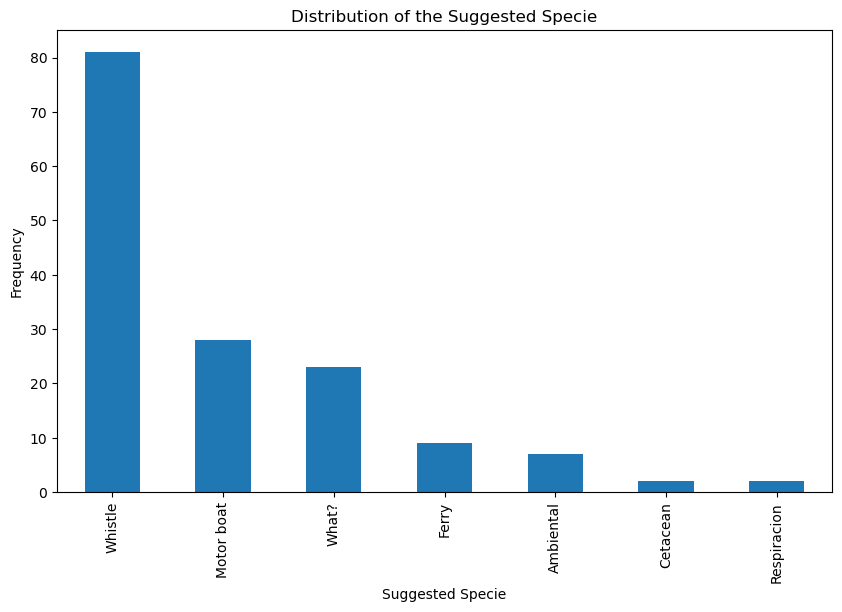

In [63]:
import matplotlib.pyplot as plt
# Distribution of the Altertative
plt.figure(figsize=(10, 6))
df['Suggested Specie'].value_counts().plot(kind='bar')
plt.xlabel('Suggested Specie')
plt.ylabel('Frequency')
plt.title('Distribution of the Suggested Specie')
plt.show()

In [64]:
df

,File,SegmentFile,StartSecond,EndSecond,StartRecordingTimestamp,StartAnnotationTimestamp,EndAnnotationTimestamp,Specie,Validation,Suggested Specie,ConfidenceScore
0,channelA_2024-05-27_21-43-19.WAV,channelA_2024-05-27_21-43-19_48kHz_286_293_0.5...,286.0,293.0,2024-05-27 21:43:19,2024-05-27 21:48:05,2024-05-27 21:48:12,Whistle,1.0,Whistle,0.56
1,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_0_5_0.98.WAV,0.0,5.0,2024-05-27 21:48:19,2024-05-27 21:48:19,2024-05-27 21:48:24,Whistle,1.0,Whistle,0.98
2,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_103_110_0.9...,103.0,110.0,2024-05-27 21:48:19,2024-05-27 21:50:02,2024-05-27 21:50:09,Whistle,1.0,Whistle,0.91
3,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_106_113_0.9...,106.0,113.0,2024-05-27 21:48:19,2024-05-27 21:50:05,2024-05-27 21:50:12,Whistle,1.0,Whistle,0.98
4,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_109_116_1.0...,109.0,116.0,2024-05-27 21:48:19,2024-05-27 21:50:08,2024-05-27 21:50:15,Whistle,1.0,Whistle,1.0
...,...,...,...,...,...,...,...,...,...,...,...
150,channelA_2024-06-12_16-00-33.WAV,channelA_2024-06-12_16-00-33_48kHz_106_113_0.6...,106.0,113.0,2024-06-12 16:00:33,2024-06-12 16:02:19,2024-06-12 16:02:26,Whistle,0.0,Ferry,0.62
151,channelA_2024-06-12_16-15-33.WAV,channelA_2024-06-12_16-15-33_48kHz_25_32_0.58.WAV,25.0,32.0,2024-06-12 16:15:33,2024-06-12 16:15:58,2024-06-12 16:16:05,Whistle,0.0,Ferry,0.58
152,channelA_2024-06-12_16-15-33.WAV,channelA_2024-06-12_16-15-33_48kHz_34_41_0.61.WAV,34.0,41.0,2024-06-12 16:15:33,2024-06-12 16:16:07,2024-06-12 16:16:14,Whistle,0.0,Ferry,0.61
153,channelA_2024-06-12_16-15-33.WAV,channelA_2024-06-12_16-15-33_48kHz_40_47_0.61.WAV,40.0,47.0,2024-06-12 16:15:33,2024-06-12 16:16:13,2024-06-12 16:16:20,Whistle,0.0,Ferry,0.61


In [65]:
df["Suggested Specie"].unique()

array(['Whistle', 'Motor boat', 'What?', 'Ferry', nan, 'Cetacean',
       'Ambiental', 'Respiracion'], dtype=object)

In [66]:
# count number of rows with each Suggested Specie
df['Suggested Specie'].value_counts()

Suggested Specie
Whistle        81
Motor boat     28
What?          23
Ferry           9
Ambiental       7
Cetacean        2
Respiracion     2
Name: count, dtype: int64

In [67]:
# delete rows where Suggested Specie is " "
# df = df[df['Suggested Specie'] != " "]
# delete rows with Suggestions = WHAT?
df = df[df['Suggested Specie'] != 'WHAT?']

In [68]:
df.loc[df['Suggested Specie'].isin(['Ferry_Fast ferry']), 'Suggested Specie'] = 'Ferry_FastFerry'
df.loc[df['Suggested Specie'].isin(['Ferry']), 'Suggested Specie'] = 'Ferry_FastFerry'
df.loc[df['Suggested Specie'].isin(['Motor boat']), 'Suggested Specie'] = 'Motor_boat'
df.loc[df['Suggested Specie'].isin(['Big motor boat']), 'Suggested Specie'] = 'Motor_boat'
df.loc[df['Suggested Specie'].isin(['Respiracion']), 'Suggested Specie'] = 'Breath'

In [69]:
# whistle, human_diver_1_breath, human_diver_2_wee, Ferry_FastFerry, Motor_boat
# # If CommonDolphin, KillerWhale or Cetacean, set Suggested Specie to Whistle
# df.loc[df['Suggested Specie'].isin(['CommonDolphin', 'KillerWhale', 'Cetacean']), 'Suggested Specie'] = 'Whistle'
# # If Human_diver set to Human_diver_1_breath
# df.loc[df['Suggested Specie'].isin(['Human_diver']), 'Suggested Specie'] = 'Human_diver_1_breath'
# # If Diver+wee set to Human_diver_2_wee
# df.loc[df['Suggested Specie'].isin(['Diver+wee']), 'Suggested Specie'] = 'Human_diver_2_wee'
# # If Motor boat set to Motor_boat
# df.loc[df['Suggested Specie'].isin(['Motor boat']), 'Suggested Specie'] = 'Motor_boat'
# # If Ferry set to Ferry_FastFerry
# df.loc[df['Suggested Specie'].isin(['Ferry']), 'Suggested Specie'] = 'Ferry_FastFerry'
df

,File,SegmentFile,StartSecond,EndSecond,StartRecordingTimestamp,StartAnnotationTimestamp,EndAnnotationTimestamp,Specie,Validation,Suggested Specie,ConfidenceScore
0,channelA_2024-05-27_21-43-19.WAV,channelA_2024-05-27_21-43-19_48kHz_286_293_0.5...,286.0,293.0,2024-05-27 21:43:19,2024-05-27 21:48:05,2024-05-27 21:48:12,Whistle,1.0,Whistle,0.56
1,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_0_5_0.98.WAV,0.0,5.0,2024-05-27 21:48:19,2024-05-27 21:48:19,2024-05-27 21:48:24,Whistle,1.0,Whistle,0.98
2,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_103_110_0.9...,103.0,110.0,2024-05-27 21:48:19,2024-05-27 21:50:02,2024-05-27 21:50:09,Whistle,1.0,Whistle,0.91
3,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_106_113_0.9...,106.0,113.0,2024-05-27 21:48:19,2024-05-27 21:50:05,2024-05-27 21:50:12,Whistle,1.0,Whistle,0.98
4,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_109_116_1.0...,109.0,116.0,2024-05-27 21:48:19,2024-05-27 21:50:08,2024-05-27 21:50:15,Whistle,1.0,Whistle,1.0
...,...,...,...,...,...,...,...,...,...,...,...
150,channelA_2024-06-12_16-00-33.WAV,channelA_2024-06-12_16-00-33_48kHz_106_113_0.6...,106.0,113.0,2024-06-12 16:00:33,2024-06-12 16:02:19,2024-06-12 16:02:26,Whistle,0.0,Ferry_FastFerry,0.62
151,channelA_2024-06-12_16-15-33.WAV,channelA_2024-06-12_16-15-33_48kHz_25_32_0.58.WAV,25.0,32.0,2024-06-12 16:15:33,2024-06-12 16:15:58,2024-06-12 16:16:05,Whistle,0.0,Ferry_FastFerry,0.58
152,channelA_2024-06-12_16-15-33.WAV,channelA_2024-06-12_16-15-33_48kHz_34_41_0.61.WAV,34.0,41.0,2024-06-12 16:15:33,2024-06-12 16:16:07,2024-06-12 16:16:14,Whistle,0.0,Ferry_FastFerry,0.61
153,channelA_2024-06-12_16-15-33.WAV,channelA_2024-06-12_16-15-33_48kHz_40_47_0.61.WAV,40.0,47.0,2024-06-12 16:15:33,2024-06-12 16:16:13,2024-06-12 16:16:20,Whistle,0.0,Ferry_FastFerry,0.61


In [70]:
# # take only Ferry_FastFerry and Motor_boat and save csv
# df = df[df['Suggested Specie'].isin(['Ferry_FastFerry', 'Motor_boat'])]
# # delete confidence score and specie
# df = df.drop(columns=['ConfidenceScore', 'Specie', 'Validation'])
# # Change Suggested Specie to Annotation
# df = df.rename(columns={'Suggested Specie': 'Annotation'})
# df.to_csv('../CSVs/NOWOPAMDay_456/Ferry_FastFerry_Motor_boat.csv', index=False)

In [71]:
# delete confidence score and specie
# df = df.drop(columns=['ConfidenceScore', 'Specie', 'Validation'])
# # Change Suggested Specie to Annotation
# df = df.rename(columns={'Suggested Specie': 'Annotation'})
# # save csv as wopam_day_annotations.csv
# df.to_csv('wopam_day_annotations.csv', index=False)

In [72]:
df

,File,SegmentFile,StartSecond,EndSecond,StartRecordingTimestamp,StartAnnotationTimestamp,EndAnnotationTimestamp,Specie,Validation,Suggested Specie,ConfidenceScore
0,channelA_2024-05-27_21-43-19.WAV,channelA_2024-05-27_21-43-19_48kHz_286_293_0.5...,286.0,293.0,2024-05-27 21:43:19,2024-05-27 21:48:05,2024-05-27 21:48:12,Whistle,1.0,Whistle,0.56
1,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_0_5_0.98.WAV,0.0,5.0,2024-05-27 21:48:19,2024-05-27 21:48:19,2024-05-27 21:48:24,Whistle,1.0,Whistle,0.98
2,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_103_110_0.9...,103.0,110.0,2024-05-27 21:48:19,2024-05-27 21:50:02,2024-05-27 21:50:09,Whistle,1.0,Whistle,0.91
3,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_106_113_0.9...,106.0,113.0,2024-05-27 21:48:19,2024-05-27 21:50:05,2024-05-27 21:50:12,Whistle,1.0,Whistle,0.98
4,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_109_116_1.0...,109.0,116.0,2024-05-27 21:48:19,2024-05-27 21:50:08,2024-05-27 21:50:15,Whistle,1.0,Whistle,1.0
...,...,...,...,...,...,...,...,...,...,...,...
150,channelA_2024-06-12_16-00-33.WAV,channelA_2024-06-12_16-00-33_48kHz_106_113_0.6...,106.0,113.0,2024-06-12 16:00:33,2024-06-12 16:02:19,2024-06-12 16:02:26,Whistle,0.0,Ferry_FastFerry,0.62
151,channelA_2024-06-12_16-15-33.WAV,channelA_2024-06-12_16-15-33_48kHz_25_32_0.58.WAV,25.0,32.0,2024-06-12 16:15:33,2024-06-12 16:15:58,2024-06-12 16:16:05,Whistle,0.0,Ferry_FastFerry,0.58
152,channelA_2024-06-12_16-15-33.WAV,channelA_2024-06-12_16-15-33_48kHz_34_41_0.61.WAV,34.0,41.0,2024-06-12 16:15:33,2024-06-12 16:16:07,2024-06-12 16:16:14,Whistle,0.0,Ferry_FastFerry,0.61
153,channelA_2024-06-12_16-15-33.WAV,channelA_2024-06-12_16-15-33_48kHz_40_47_0.61.WAV,40.0,47.0,2024-06-12 16:15:33,2024-06-12 16:16:13,2024-06-12 16:16:20,Whistle,0.0,Ferry_FastFerry,0.61


In [73]:
# show Validation nan
# Drop rows where Validation is nan
df = df.dropna(subset=['Validation'])

In [74]:
# Make Validation integer
df["Validation"] = df["Validation"].astype(int)
df["Validation Value"] = df["Validation"].map({'Whistle': 1, 'Other specie': 0, 'Unknown': -2, 'Whistle': 2, 'Incorrect': -1})

/tmp/ipykernel_63013/2998985122.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Validation"] = df["Validation"].astype(int)
/tmp/ipykernel_63013/2998985122.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Validation Value"] = df["Validation"].map({'Whistle': 1, 'Other specie': 0, 'Unknown': -2, 'Whistle': 2, 'Incorrect': -1})


In [75]:
# Change validation values to Correct if 1, Other specie if 0, Unknown if -2, Bird if 2
df['Validation Value'] = df['Validation'].map({1: 'Whistle', 0: 'Other', -2: 'Unknown', 2: 'Whistle', -1: 'Incorrect'})
df

/tmp/ipykernel_63013/3866937667.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Validation Value'] = df['Validation'].map({1: 'Whistle', 0: 'Other', -2: 'Unknown', 2: 'Whistle', -1: 'Incorrect'})


,File,SegmentFile,StartSecond,EndSecond,StartRecordingTimestamp,StartAnnotationTimestamp,EndAnnotationTimestamp,Specie,Validation,Suggested Specie,ConfidenceScore,Validation Value
0,channelA_2024-05-27_21-43-19.WAV,channelA_2024-05-27_21-43-19_48kHz_286_293_0.5...,286.0,293.0,2024-05-27 21:43:19,2024-05-27 21:48:05,2024-05-27 21:48:12,Whistle,1,Whistle,0.56,Whistle
1,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_0_5_0.98.WAV,0.0,5.0,2024-05-27 21:48:19,2024-05-27 21:48:19,2024-05-27 21:48:24,Whistle,1,Whistle,0.98,Whistle
2,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_103_110_0.9...,103.0,110.0,2024-05-27 21:48:19,2024-05-27 21:50:02,2024-05-27 21:50:09,Whistle,1,Whistle,0.91,Whistle
3,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_106_113_0.9...,106.0,113.0,2024-05-27 21:48:19,2024-05-27 21:50:05,2024-05-27 21:50:12,Whistle,1,Whistle,0.98,Whistle
4,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_109_116_1.0...,109.0,116.0,2024-05-27 21:48:19,2024-05-27 21:50:08,2024-05-27 21:50:15,Whistle,1,Whistle,1.0,Whistle
...,...,...,...,...,...,...,...,...,...,...,...,...
150,channelA_2024-06-12_16-00-33.WAV,channelA_2024-06-12_16-00-33_48kHz_106_113_0.6...,106.0,113.0,2024-06-12 16:00:33,2024-06-12 16:02:19,2024-06-12 16:02:26,Whistle,0,Ferry_FastFerry,0.62,Other
151,channelA_2024-06-12_16-15-33.WAV,channelA_2024-06-12_16-15-33_48kHz_25_32_0.58.WAV,25.0,32.0,2024-06-12 16:15:33,2024-06-12 16:15:58,2024-06-12 16:16:05,Whistle,0,Ferry_FastFerry,0.58,Other
152,channelA_2024-06-12_16-15-33.WAV,channelA_2024-06-12_16-15-33_48kHz_34_41_0.61.WAV,34.0,41.0,2024-06-12 16:15:33,2024-06-12 16:16:07,2024-06-12 16:16:14,Whistle,0,Ferry_FastFerry,0.61,Other
153,channelA_2024-06-12_16-15-33.WAV,channelA_2024-06-12_16-15-33_48kHz_40_47_0.61.WAV,40.0,47.0,2024-06-12 16:15:33,2024-06-12 16:16:13,2024-06-12 16:16:20,Whistle,0,Ferry_FastFerry,0.61,Other


/tmp/ipykernel_63013/726100040.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ConfidenceScore'] = pd.to_numeric(df['ConfidenceScore'])


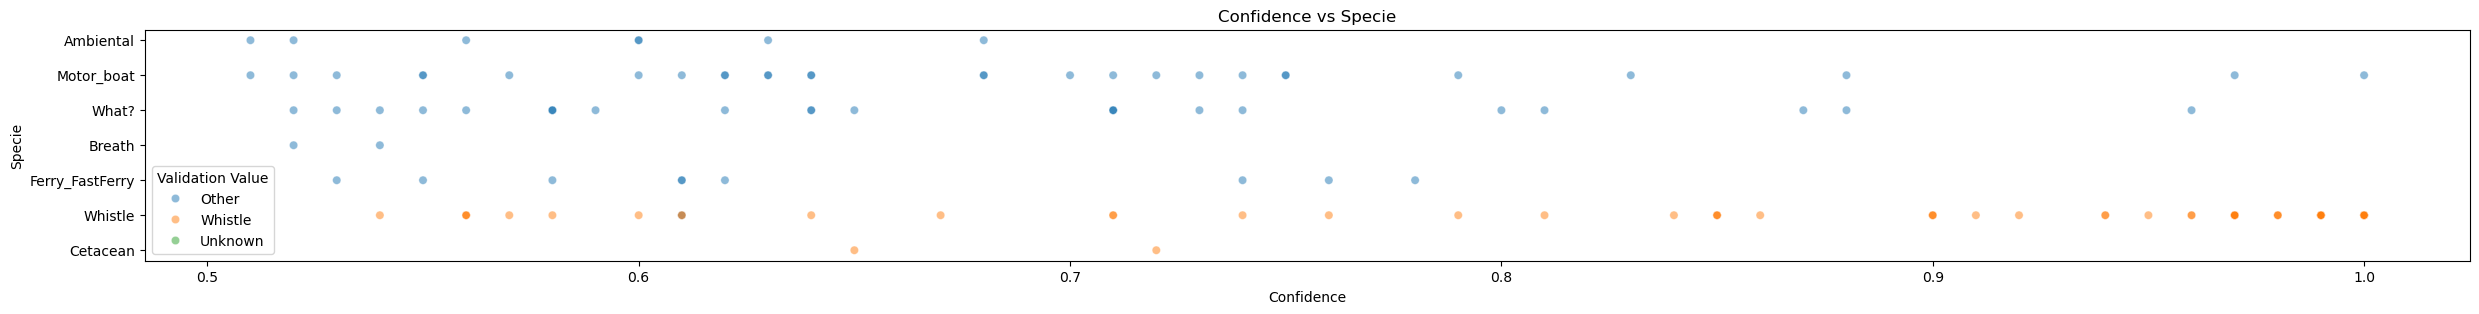

In [76]:
import seaborn as sns

# Convert ConfidenceScore to numeric values
df['ConfidenceScore'] = pd.to_numeric(df['ConfidenceScore'])

# Sort the dataframe by ConfidenceScore
df_sorted = df.sort_values(by='ConfidenceScore')

# Scatter plot with the Validation, Confidence and Specie
plt.figure(figsize=(30, 3))
sns.scatterplot(data=df_sorted, x='ConfidenceScore', y='Suggested Specie', hue="Validation Value", alpha=0.5)
plt.xlabel('Confidence')
plt.ylabel('Specie')
plt.title('Confidence vs Specie')
plt.show()

/tmp/ipykernel_63013/4255151684.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ConfidenceScore'] = pd.to_numeric(df['ConfidenceScore'])


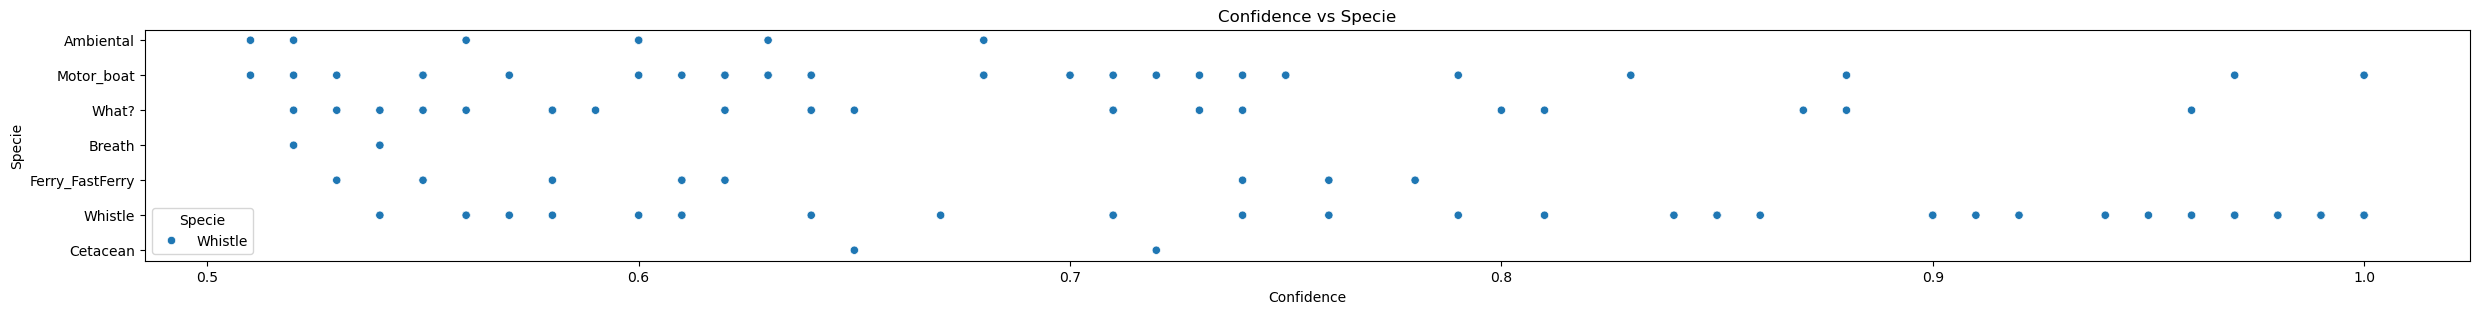

In [77]:
import seaborn as sns

# Convert ConfidenceScore to numeric values
df['ConfidenceScore'] = pd.to_numeric(df['ConfidenceScore'])

# Sort the dataframe by ConfidenceScore
df_sorted = df.sort_values(by='ConfidenceScore')

# Scatter plot with the Validation, Confidence and Specie
plt.figure(figsize=(30, 3))
sns.scatterplot(data=df_sorted, x='ConfidenceScore', y='Suggested Specie', hue="Specie", alpha=1)
plt.xlabel('Confidence')
plt.ylabel('Specie')
plt.title('Confidence vs Specie')
plt.show()

/tmp/ipykernel_63013/494332848.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ConfidenceScore'] = pd.to_numeric(df['ConfidenceScore'])
/tmp/ipykernel_63013/494332848.py:11: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(data=df_sorted, x='ConfidenceScore', y='Specie', hue="Validation", alpha=0.5, palette=["C1", "C2", "C0"], s=100)


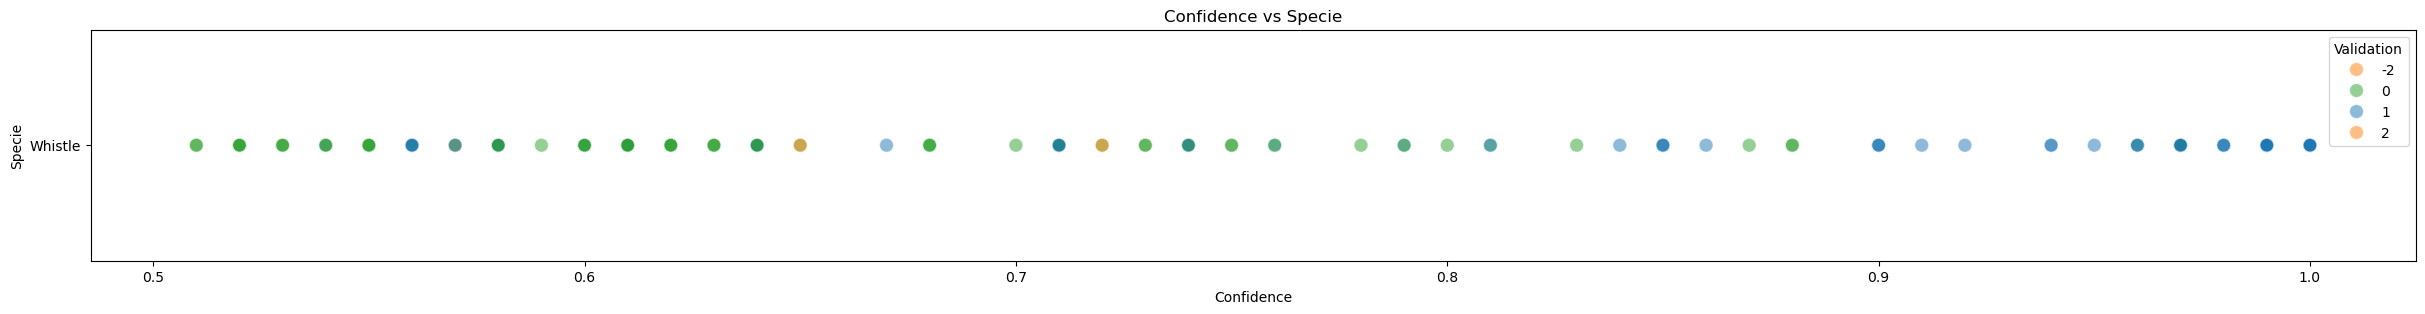

In [78]:
import seaborn as sns

# Convert ConfidenceScore to numeric values
df['ConfidenceScore'] = pd.to_numeric(df['ConfidenceScore'])

# Sort the dataframe by ConfidenceScore
df_sorted = df.sort_values(by='ConfidenceScore')

# Scatter plot with the Validation, Confidence and Specie
plt.figure(figsize=(30, 3))
sns.scatterplot(data=df_sorted, x='ConfidenceScore', y='Specie', hue="Validation", alpha=0.5, palette=["C1", "C2", "C0"], s=100)
plt.xlabel('Confidence')
plt.ylabel('Specie')
plt.title('Confidence vs Specie')
plt.show()

In [79]:
# df_regression

In [80]:
# Logistic regression for df, set Validation to 1 if Whistle or Cetacean and 0 if Other specie or Unknown
df_regression = df.copy()
df_regression.loc[df_regression['Validation'] == 1, 'Validation'] = 1
df_regression.loc[df_regression['Validation'] == 2, 'Validation'] = 1
df_regression.loc[df_regression['Validation'] == 0, 'Validation'] = 0
df_regression.loc[df_regression['Validation'] == -2, 'Validation'] = 0
df_regression.loc[df_regression['Validation'] == -1, 'Validation'] = 0

# Drop columns that are not needed
# df_regression = df_regression.drop(columns=['Specie', 'File', 'SegmentFile', 'StartSecond', 'EndSecond', 'StartRecordingTimestamp', 'StartAnnotationTimestamp', 'EndAnnotationTimestamp', 'Suggested Specie', 'Validation Value'])

Model's probability range: 0.19 to 1.00
Threshold at 47% correctness:
- Logit Score: 1.64
- Confidence Score: 0.84
- Positives: 69
- Real Positives: 82
- True Positives: 63
- True Positives Lost: 19
- False Positives Included: 6
- False Positives not Included: 65


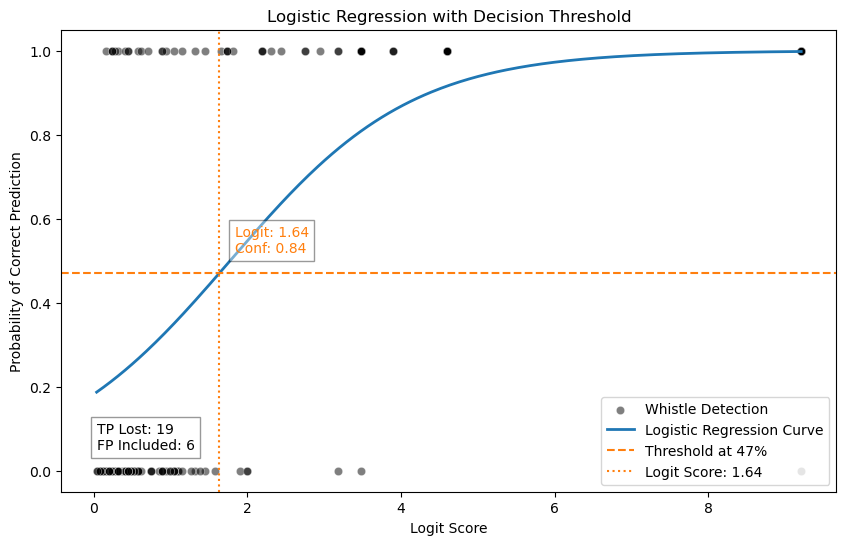

Percentage of missing positives: 0.19%


In [88]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import seaborn as sns

# 1. Fix Confidence Score to Avoid Log Errors (Clip between [0.0001, 0.9999])
df_regression["ConfidenceScore"] = np.clip(df_regression["ConfidenceScore"], 0.0001, 0.9999)

# 2. Convert Confidence Score to Logit Score
df_regression["LogitScore"] = np.round(np.log(df_regression["ConfidenceScore"] / (1 - df_regression["ConfidenceScore"])), 3)

# 3. Extract Features and Target
X = df_regression[['LogitScore']].values  # Use Logit Score as feature
y = df_regression['Validation'].values  # Target variable

# 4. Fit Logistic Regression Model
model = LogisticRegression()
model.fit(X, y)

# 5. Generate Smooth Curve Data for Plotting
X_curve = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_curve_proba = model.predict_proba(X_curve)[:, 1]  # Probability for class 1

# 6. Check Min and Max Confidence Score from Model
min_confidence = y_curve_proba.min()
max_confidence = y_curve_proba.max()
print(f"Model's probability range: {min_confidence:.2f} to {max_confidence:.2f}")

# 7. User-defined Correctness Threshold (Y-axis value)
correctness_threshold = 0.47  # Change this value to test different thresholds

# 8. Find Logit Score for Given Probability (X-axis intersection)
logit_threshold = np.interp(correctness_threshold, y_curve_proba, X_curve.flatten())

# 9. Convert Logit Score to Confidence Score using Sigmoid Function
confidence_threshold = 1 / (1 + np.exp(-logit_threshold))

# 10. Count True Positives Lost & False Positives Included
predicted_labels = (X >= logit_threshold).astype(int).flatten()
total_positives = np.sum(y == 1)
true_positives = np.sum((predicted_labels == 1) & (y == 1))
false_positives = np.sum((predicted_labels == 1) & (y == 0))

# 11. Plot the Data
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X.flatten(), y=y, color='black', alpha=0.5, label="Whistle Detection")  # Black dots
plt.plot(X_curve, y_curve_proba, color='C0', linewidth=2, label="Logistic Regression Curve")  # Blue curve

# 12. Add Threshold Lines
plt.axhline(correctness_threshold, color='C1', linestyle='dashed', label=f"Threshold at {correctness_threshold*100:.0f}%")
plt.axvline(logit_threshold, color='C1', linestyle='dotted', label=f"Logit Score: {logit_threshold:.2f}")

# 13. Add Text Annotations on Plot
plt.text(logit_threshold + 0.2, correctness_threshold + 0.05, 
         f"Logit: {logit_threshold:.2f}\nConf: {confidence_threshold:.2f}", 
         color='C1', fontsize=10, bbox=dict(facecolor='white', alpha=0.4))

plt.text(X.min(), 0.05, 
         f"TP Lost: {total_positives - true_positives}\nFP Included: {false_positives}", 
         color='black', fontsize=10, bbox=dict(facecolor='white', alpha=0.4))

# Labels and Title
plt.xlabel('Logit Score')
plt.ylabel('Probability of Correct Prediction')
plt.title('Logistic Regression with Decision Threshold')
plt.legend()

# 14. Print Threshold Details in Console
print(f"Threshold at {correctness_threshold*100:.0f}% correctness:")
print(f"- Logit Score: {logit_threshold:.2f}")
print(f"- Confidence Score: {confidence_threshold:.2f}")
print(f"- Positives: {true_positives + false_positives}")
print(f"- Real Positives: {total_positives}")
print(f"- True Positives: {true_positives}")
print(f"- True Positives Lost: {total_positives - true_positives}")
print(f"- False Positives Included: {false_positives}")
print(f"- False Positives not Included: {np.sum((predicted_labels == 0) & (y == 0))}")

plt.show()

missing_positives = ((total_positives - (true_positives + false_positives))) / (true_positives + false_positives)
print(f"Percentage of missing positives: {missing_positives:.2f}%")

Punto de inflexión (índice en curva PR): 32
Threshold (confidence) en inflexión: 0.86
Codo / Knee (índice en curva PR): 29
Threshold (confidence) en codo: 0.83


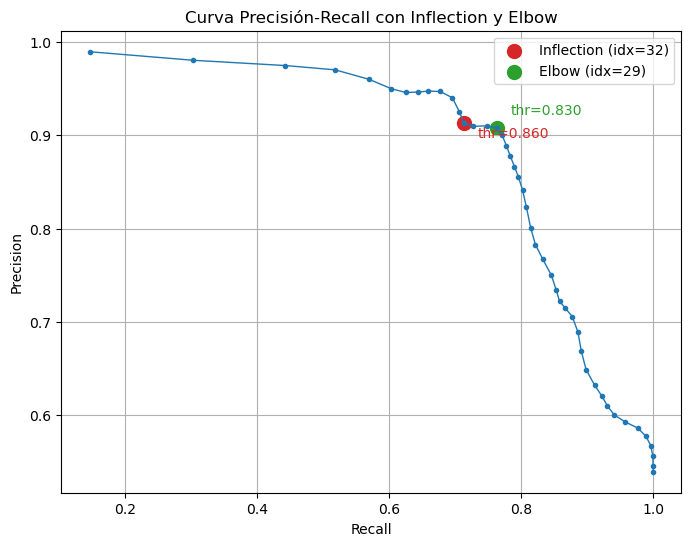

In [87]:
# Calcular curva PR, punto de inflexión (máxima curvatura), codo (knee) y confidence score en esos puntos
from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

y_true = df_regression["Validation"].values
y_proba = df_regression["ConfidenceScore"].values

precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
# suavizar curva

precision = gaussian_filter1d(precision, sigma=1)
recall = gaussian_filter1d(recall, sigma=1)
# precision, recall tienen longitud m; thresholds tiene longitud m-1
m = len(precision)

# 1) Punto de inflexión: máxima curvatura estimada por segunda diferencia en precision
if m >= 3:
    d2p = np.diff(precision, n=2)  # length m-2, corresponds to indices 1..m-2
    inflection_rel_idx = np.argmax(np.abs(d2p)) + 1  # map back to precision/recall index
else:
    inflection_rel_idx = None

# 2) Codo (knee): punto con máxima distancia al segmento que une endpoints (recall[0],precision[0])-(recall[-1],precision[-1])
if m >= 3:
    x0, y0 = recall[0], precision[0]
    x1, y1 = recall[-1], precision[-1]
    # vector line
    vx, vy = x1 - x0, y1 - y0
    pts_x, pts_y = recall, precision
    # distancia cruz producto / norma
    num = np.abs(vy * (pts_x - x0) - vx * (pts_y - y0))
    den = np.hypot(vx, vy)
    distances = num / (den + 1e-12)
    # exclude endpoints
    distances[0] = 0
    distances[-1] = 0
    elbow_rel_idx = np.argmax(distances)
else:
    elbow_rel_idx = None

# Map indices to thresholds (confidence score): threshold for point j is thresholds[j-1] (j>=1 and j<=m-2)
def idx_to_threshold(j):
    if j is None:
        return None
    if 1 <= j <= m-2:
        return thresholds[j-1]
    # if j==0 or j==m-1 no direct threshold (choose nearest)
    if j == 0:
        return thresholds[0]
    if j == m-1:
        return thresholds[-1]
    return None

inflection_threshold = idx_to_threshold(inflection_rel_idx)
elbow_threshold = idx_to_threshold(elbow_rel_idx)

# Mostrar resultados
print("Punto de inflexión (índice en curva PR):", inflection_rel_idx)
print("Threshold (confidence) en inflexión:", inflection_threshold)
print("Codo / Knee (índice en curva PR):", elbow_rel_idx)
print("Threshold (confidence) en codo:", elbow_threshold)

# Graficar y marcar puntos
plt.figure(figsize=(8,6))
plt.plot(recall, precision, marker='.', lw=1)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precisión-Recall con Inflection y Elbow')
plt.grid(True)

if inflection_rel_idx is not None:
    plt.scatter([recall[inflection_rel_idx]], [precision[inflection_rel_idx]], color='C3', s=100, label=f'Inflection (idx={inflection_rel_idx})')
    plt.annotate(f"thr={inflection_threshold:.3f}" if inflection_threshold is not None else "thr=None",
                 (recall[inflection_rel_idx], precision[inflection_rel_idx]), xytext=(10,-10), textcoords='offset points', color='C3')

if elbow_rel_idx is not None:
    plt.scatter([recall[elbow_rel_idx]], [precision[elbow_rel_idx]], color='C2', s=100, label=f'Elbow (idx={elbow_rel_idx})')
    plt.annotate(f"thr={elbow_threshold:.3f}" if elbow_threshold is not None else "thr=None",
                 (recall[elbow_rel_idx], precision[elbow_rel_idx]), xytext=(10,10), textcoords='offset points', color='C2')

plt.legend(loc="best")
plt.show()

Model's probability range: 0.19 to 1.00
Threshold at 40% correctness:
- Logit Score: 1.30
- Confidence Score: 0.79
- Real Positives: 82
- True Positives: 65
- True Positives Lost: 17
- False Positives: 71
- False Positives Included: 10
- False Positives not Included: 61


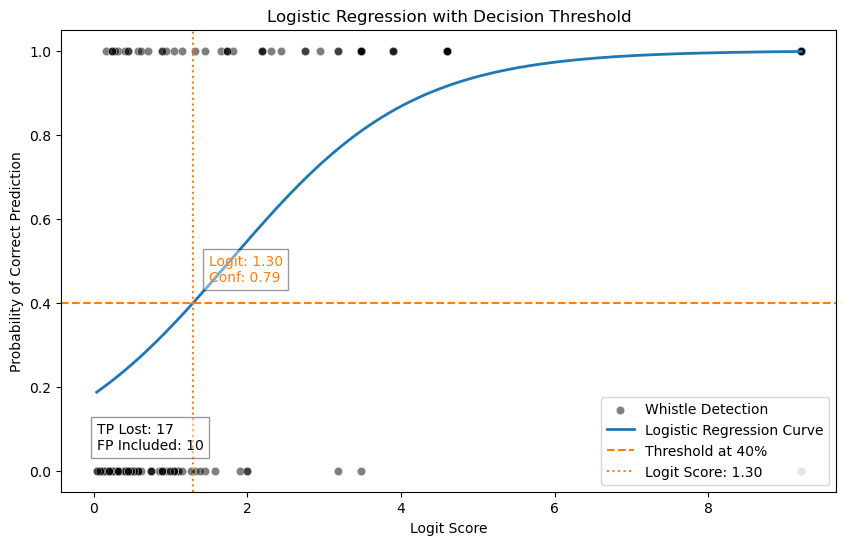

Percentage of missing positives: 0.09%


In [89]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import seaborn as sns

# 1. Fix Confidence Score to Avoid Log Errors (Clip between [0.0001, 0.9999])
df_regression["ConfidenceScore"] = np.clip(df_regression["ConfidenceScore"], 0.0001, 0.9999)

# 2. Convert Confidence Score to Logit Score
df_regression["LogitScore"] = np.round(np.log(df_regression["ConfidenceScore"] / (1 - df_regression["ConfidenceScore"])), 3)

# 3. Extract Features and Target
X = df_regression[['LogitScore']].values  # Use Logit Score as feature
y = df_regression['Validation'].values  # Target variable

# 4. Fit Logistic Regression Model
model = LogisticRegression()
model.fit(X, y)

# 5. Generate Smooth Curve Data for Plotting
X_curve = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_curve_proba = model.predict_proba(X_curve)[:, 1]  # Probability for class 1

# 6. Check Min and Max Confidence Score from Model
min_confidence = y_curve_proba.min()
max_confidence = y_curve_proba.max()
print(f"Model's probability range: {min_confidence:.2f} to {max_confidence:.2f}")

# 7. User-defined Correctness Threshold (Y-axis value)
correctness_threshold = 0.4  # Change this value to test different thresholds

# 8. Find Logit Score for Given Probability (X-axis intersection)
logit_threshold = np.interp(correctness_threshold, y_curve_proba, X_curve.flatten())

# 9. Convert Logit Score to Confidence Score using Sigmoid Function
confidence_threshold = 1 / (1 + np.exp(-logit_threshold))

# 10. Count True Positives Lost & False Positives Included
predicted_labels = (X >= logit_threshold).astype(int).flatten()
total_positives = np.sum(y == 1)
total_negatives = np.sum(y == 0)
true_positives = np.sum((predicted_labels == 1) & (y == 1))
false_positives = np.sum((predicted_labels == 1) & (y == 0))

# 11. Plot the Data
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X.flatten(), y=y, color='black', alpha=0.5, label="Whistle Detection")  # Black dots
plt.plot(X_curve, y_curve_proba, color='C0', linewidth=2, label="Logistic Regression Curve")  # Blue curve

# 12. Add Threshold Lines
plt.axhline(correctness_threshold, color='C1', linestyle='dashed', label=f"Threshold at {correctness_threshold*100:.0f}%")
plt.axvline(logit_threshold, color='C1', linestyle='dotted', label=f"Logit Score: {logit_threshold:.2f}")

# 13. Add Text Annotations on Plot
plt.text(logit_threshold + 0.2, correctness_threshold + 0.05, 
         f"Logit: {logit_threshold:.2f}\nConf: {confidence_threshold:.2f}", 
         color='C1', fontsize=10, bbox=dict(facecolor='white', alpha=0.4))

plt.text(X.min(), 0.05, 
         f"TP Lost: {total_positives - true_positives}\nFP Included: {false_positives}", 
         color='black', fontsize=10, bbox=dict(facecolor='white', alpha=0.4))

# Labels and Title
plt.xlabel('Logit Score')
plt.ylabel('Probability of Correct Prediction')
plt.title('Logistic Regression with Decision Threshold')
plt.legend()

# 14. Print Threshold Details in Console
print(f"Threshold at {correctness_threshold*100:.0f}% correctness:")
print(f"- Logit Score: {logit_threshold:.2f}")
print(f"- Confidence Score: {confidence_threshold:.2f}")
print(f"- Real Positives: {total_positives}")
print(f"- True Positives: {true_positives}")
print(f"- True Positives Lost: {total_positives - true_positives}")
print(f"- False Positives: {total_negatives}")
print(f"- False Positives Included: {false_positives}")
print(f"- False Positives not Included: {np.sum((predicted_labels == 0) & (y == 0))}")

plt.show()

missing_positives = ((total_positives - (true_positives + false_positives))) / (true_positives + false_positives)
print(f"Percentage of missing positives: {missing_positives:.2f}%")

## Calcular punto de inflexión

Punto de inflexión (Logit score): 1.7775
Probabilidad en inflexión (modelo): 0.5000
Confidence score correspondiente (sigmoid): 0.8554
Valor más cercano en la malla: Logit 1.7881, Prob 0.5023 (índice 57)


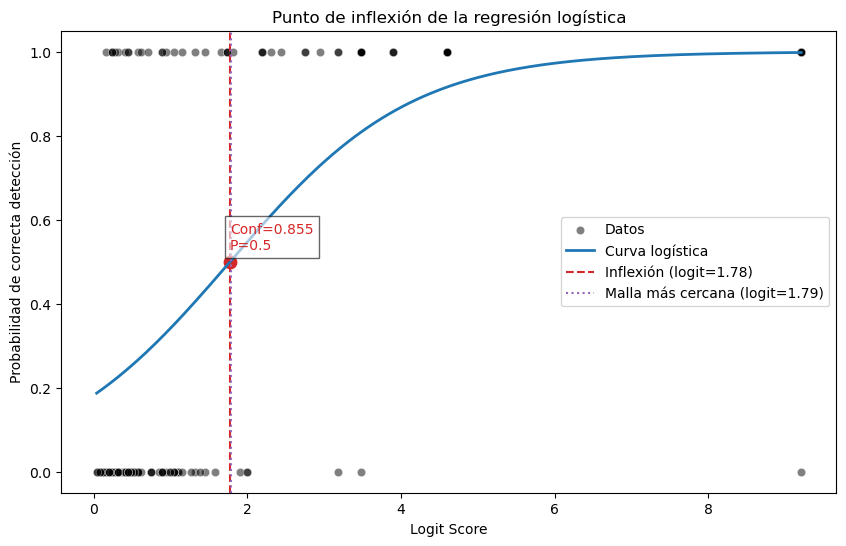

In [38]:
# Calcular punto de inflexión de la regresión logística (probabilidad = 0.5)
coef = model.coef_.ravel()[0]
intercept = model.intercept_[0]
logit_inflexion = -intercept / coef
confidence_inflexion = 1 / (1 + np.exp(-logit_inflexion))
prob_at_inflexion = model.predict_proba(np.array([[logit_inflexion]]))[:, 1][0]

# Información adicional: índice y valor en la malla X_curve / y_curve_proba más cercano
idx_closest = np.argmin(np.abs(X_curve.flatten() - logit_inflexion))
x_closest = X_curve.flatten()[idx_closest]
y_closest = y_curve_proba[idx_closest]

print(f"Punto de inflexión (Logit score): {logit_inflexion:.4f}")
print(f"Probabilidad en inflexión (modelo): {prob_at_inflexion:.4f}")
print(f"Confidence score correspondiente (sigmoid): {confidence_inflexion:.4f}")
print(f"Valor más cercano en la malla: Logit {x_closest:.4f}, Prob {y_closest:.4f} (índice {idx_closest})")

# Mostrar en la gráfica
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X.flatten(), y=y, color='black', alpha=0.5, label="Datos")
plt.plot(X_curve, y_curve_proba, color='C0', linewidth=2, label="Curva logística")
plt.axvline(logit_inflexion, color='C3', linestyle='--', label=f"Inflexión (logit={logit_inflexion:.2f})")
plt.axvline(x_closest, color='C4', linestyle=':', label=f"Malla más cercana (logit={x_closest:.2f})")
plt.scatter([logit_inflexion], [prob_at_inflexion], color='C3', s=80)
plt.text(logit_inflexion, prob_at_inflexion + 0.03, f"Conf={confidence_inflexion:.3f}\nP=0.5", color='C3',
         bbox=dict(facecolor='white', alpha=0.6))
plt.xlabel('Logit Score')
plt.ylabel('Probabilidad de correcta detección')
plt.title('Punto de inflexión de la regresión logística')
plt.legend()
plt.show()


    Threshold  Precision  Recall  F1  Accuracy
10        0.6        0.6     0.9 0.7       0.7
11        0.6        0.6     0.9 0.7       0.7
12        0.6        0.7     0.9 0.8       0.7
13        0.6        0.7     0.9 0.8       0.7
14        0.6        0.7     0.9 0.8       0.7
15        0.7        0.7     0.9 0.8       0.7
16        0.7        0.7     0.9 0.8       0.7
17        0.7        0.7     0.9 0.8       0.7
18        0.7        0.7     0.9 0.8       0.8
19        0.7        0.7     0.9 0.8       0.8
20        0.7        0.7     0.9 0.8       0.8
21        0.7        0.8     0.8 0.8       0.8
22        0.7        0.8     0.8 0.8       0.8
23        0.7        0.8     0.8 0.8       0.8
24        0.7        0.8     0.8 0.8       0.8
25        0.8        0.8     0.8 0.8       0.8
26        0.8        0.9     0.8 0.8       0.8
27        0.8        0.9     0.8 0.8       0.8
28        0.8        0.9     0.8 0.8       0.8
29        0.8        0.9     0.8 0.8       0.8
30        0.8

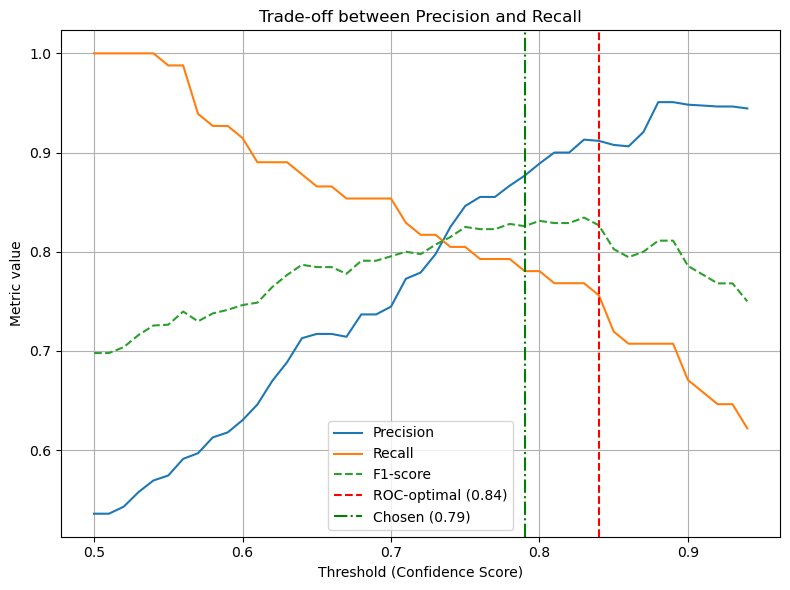

,Threshold,TP,TP (%),FP,FP (%),FN,FN (%),TN,TN (%),Precision,Recall,F1,F1_0.5,F1_1.5
0,0.7,70,85.4,25,35.2,12,14.6,46,64.8,0.7,0.9,0.8,0.8,0.8
1,0.7,70,85.4,24,33.8,12,14.6,47,66.2,0.7,0.9,0.8,0.8,0.8
2,0.7,68,82.9,20,28.2,14,17.1,51,71.8,0.8,0.8,0.8,0.8,0.8
3,0.7,67,81.7,19,26.8,15,18.3,52,73.2,0.8,0.8,0.8,0.8,0.8
4,0.7,67,81.7,17,23.9,15,18.3,54,76.1,0.8,0.8,0.8,0.8,0.8
5,0.8,66,80.5,14,19.7,16,19.5,57,80.3,0.8,0.8,0.8,0.8,0.8
6,0.8,66,80.5,12,16.9,16,19.5,59,83.1,0.8,0.8,0.8,0.8,0.8
7,0.8,65,79.3,11,15.5,17,20.7,60,84.5,0.9,0.8,0.8,0.8,0.8
8,0.8,65,79.3,11,15.5,17,20.7,60,84.5,0.9,0.8,0.8,0.8,0.8
9,0.8,65,79.3,10,14.1,17,20.7,61,85.9,0.9,0.8,0.8,0.9,0.8


In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Suponiendo que tienes las predicciones del modelo
# y las probabilidades (confidence scores del modelo original)
y_true = df_regression["Validation"].values
y_proba = df_regression["ConfidenceScore"].values

# 1. Definir un rango de umbrales
thresholds = np.arange(0.5, 0.95, 0.01)

# 2. Calcular métricas para cada umbral
metrics = []
for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    metrics.append([t, precision, recall, f1, acc])

df_metrics = pd.DataFrame(metrics, columns=['Threshold', 'Precision', 'Recall', 'F1', 'Accuracy'])

# 3. Mostrar las métricas cercanas a los valores clave (0.79 y 0.84)
df_focus = df_metrics[(df_metrics['Threshold'] >= 0.6) & (df_metrics['Threshold'] <= 0.86)]
print(df_focus.round(3))

# 4. Graficar el trade-off
plt.figure(figsize=(8,6))
plt.plot(df_metrics['Threshold'], df_metrics['Precision'], label='Precision')
plt.plot(df_metrics['Threshold'], df_metrics['Recall'], label='Recall')
plt.plot(df_metrics['Threshold'], df_metrics['F1'], label='F1-score', linestyle='--')

# Añadir líneas verticales para los umbrales clave
plt.axvline(0.84, color='r', linestyle='--', label='ROC-optimal (0.84)')
plt.axvline(0.79, color='g', linestyle='-.', label='Chosen (0.79)')

plt.xlabel('Threshold (Confidence Score)')
plt.ylabel('Metric value')
plt.title('Trade-off between Precision and Recall')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

from sklearn.metrics import confusion_matrix, fbeta_score

# Definir rango de umbrales a mostrar
thresholds_focus = np.arange(0.70, 0.90, 0.01)

rows = []
total_pos = (y_true == 1).sum()
total_neg = (y_true == 0).sum()

for t in thresholds_focus:
    y_pred = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1 = 2 * precision * recall / (precision + recall)
    f05 = fbeta_score(y_true, y_pred, beta=0.5)
    f15 = fbeta_score(y_true, y_pred, beta=1.5)
    
    rows.append({
        "Threshold": round(t,2),
        "TP": tp,
        "TP (%)": round(tp/total_pos*100,1),
        "FP": fp,
        "FP (%)": round(fp/total_neg*100,1),
        "FN": fn,
        "FN (%)": round(fn/total_pos*100,1),
        "TN": tn,
        "TN (%)": round(tn/total_neg*100,1),
        "Precision": round(precision,3),
        "Recall": round(recall,3),
        "F1": round(f1,3),
        "F1_0.5": round(f05,3),
        "F1_1.5": round(f15,3)
    })

df_summary = pd.DataFrame(rows)

# Mostrar tabla
pd.set_option("display.float_format", "{:.1f}".format)
df_summary

In [44]:
thresholds_focus = np.arange(0.75, 0.86, 0.01)  # rango de umbrales

rows = []
total_pos = (y_true == 1).sum()
total_neg = (y_true == 0).sum()

for t in thresholds_focus:
    y_pred = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1 = 2 * precision * recall / (precision + recall)
    f05 = fbeta_score(y_true, y_pred, beta=0.5)
    f15 = fbeta_score(y_true, y_pred, beta=1.5)
    
    rows.append({
        "Threshold": round(t,2),
        "TP": tp,
        "TP (%)": round(tp/total_pos*100,1),
        "FP": fp,
        "FP (%)": round(fp/total_neg*100,1),
        "FN": fn,
        "FN (%)": round(fn/total_pos*100,1),
        "TN": tn,
        "TN (%)": round(tn/total_neg*100,1),
        "Precision": round(precision,3),
        "Recall": round(recall,3),
        "TP_recovery (%)": round(recall*100,1),  # Nueva columna
        "F1": round(f1,3),
        "F1_0.5": round(f05,3),
        "F1_1.5": round(f15,3)
    })

df_summary = pd.DataFrame(rows)
df_summary

,Threshold,TP,TP (%),FP,FP (%),FN,FN (%),TN,TN (%),Precision,Recall,TP_recovery (%),F1,F1_0.5,F1_1.5
0,0.8,66,80.5,14,19.7,16,19.5,57,80.3,0.8,0.8,80.5,0.8,0.8,0.8
1,0.8,66,80.5,12,16.9,16,19.5,59,83.1,0.8,0.8,80.5,0.8,0.8,0.8
2,0.8,65,79.3,11,15.5,17,20.7,60,84.5,0.9,0.8,79.3,0.8,0.8,0.8
3,0.8,65,79.3,11,15.5,17,20.7,60,84.5,0.9,0.8,79.3,0.8,0.8,0.8
4,0.8,65,79.3,10,14.1,17,20.7,61,85.9,0.9,0.8,79.3,0.8,0.9,0.8
5,0.8,64,78.0,9,12.7,18,22.0,62,87.3,0.9,0.8,78.0,0.8,0.9,0.8
6,0.8,64,78.0,8,11.3,18,22.0,63,88.7,0.9,0.8,78.0,0.8,0.9,0.8
7,0.8,63,76.8,7,9.9,19,23.2,64,90.1,0.9,0.8,76.8,0.8,0.9,0.8
8,0.8,63,76.8,6,8.5,19,23.2,65,91.5,0.9,0.8,76.8,0.8,0.9,0.8
9,0.8,62,75.6,6,8.5,20,24.4,65,91.5,0.9,0.8,75.6,0.8,0.9,0.8


In [45]:
from sklearn.metrics import confusion_matrix, fbeta_score

thresholds_focus = np.arange(0.75, 0.86, 0.01)  # rango de umbrales
rows = []
total_pos = (y_true == 1).sum()
total_neg = (y_true == 0).sum()

for t in thresholds_focus:
    y_pred = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    recall = tp / (tp + fn)
    f15 = fbeta_score(y_true, y_pred, beta=1.5)
    fp_perc = fp / total_neg * 100
    
    rows.append({
        "Threshold": round(t,2),
        "Recall (%)": round(recall*100,1),
        "FP (%)": round(fp_perc,1),
        "F1_1.5": round(f15,3)
    })

df_summary = pd.DataFrame(rows)
df_summary


,Threshold,Recall (%),FP (%),F1_1.5
0,0.8,80.5,19.7,0.8
1,0.8,80.5,16.9,0.8
2,0.8,79.3,15.5,0.8
3,0.8,79.3,15.5,0.8
4,0.8,79.3,14.1,0.8
5,0.8,78.0,12.7,0.8
6,0.8,78.0,11.3,0.8
7,0.8,76.8,9.9,0.8
8,0.8,76.8,8.5,0.8
9,0.8,75.6,8.5,0.8


    Threshold  TP  FP  FN  TN  TP_rate  FP_rate
0        0.70  70  25  12  46    0.854    0.352
1        0.71  70  24  12  47    0.854    0.338
2        0.72  68  20  14  51    0.829    0.282
3        0.73  67  19  15  52    0.817    0.268
4        0.74  67  17  15  54    0.817    0.239
5        0.75  66  14  16  57    0.805    0.197
6        0.76  66  12  16  59    0.805    0.169
7        0.77  65  11  17  60    0.793    0.155
8        0.78  65  11  17  60    0.793    0.155
9        0.79  65  10  17  61    0.793    0.141
10       0.80  64   9  18  62    0.780    0.127
11       0.81  64   8  18  63    0.780    0.113
12       0.82  63   7  19  64    0.768    0.099
13       0.83  63   6  19  65    0.768    0.085
14       0.84  62   6  20  65    0.756    0.085
15       0.85  59   6  23  65    0.720    0.085
16       0.86  58   6  24  65    0.707    0.085
17       0.87  58   5  24  66    0.707    0.070
18       0.88  58   3  24  68    0.707    0.042
19       0.89  58   3  24  68    0.707  

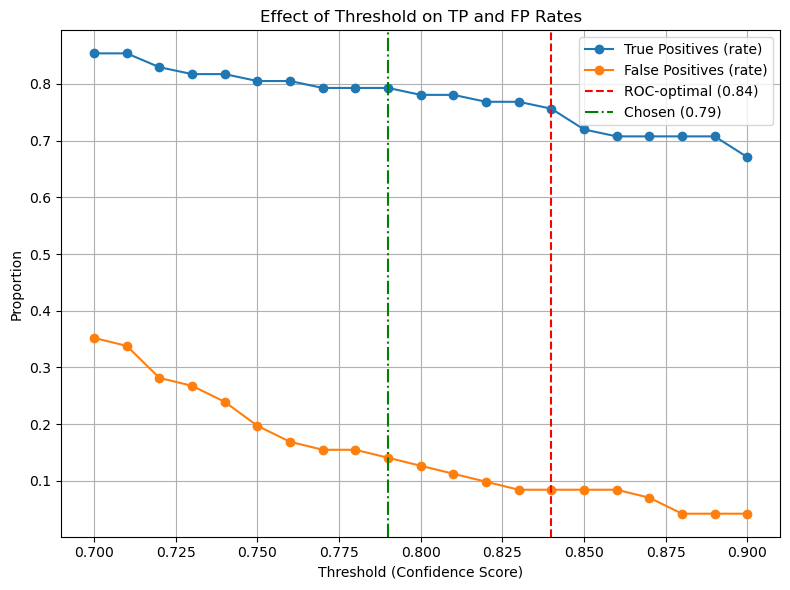

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

y_true = df_regression["Validation"].values
y_proba = df_regression["ConfidenceScore"].values

thresholds = np.arange(0.7, 0.9, 0.01)

results = []
for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    results.append([t, tp, fp, fn, tn])

df_counts = pd.DataFrame(results, columns=['Threshold', 'TP', 'FP', 'FN', 'TN'])

# Calcular también proporciones respecto al total de positivos/negativos
total_pos = (y_true == 1).sum()
total_neg = (y_true == 0).sum()
df_counts["TP_rate"] = df_counts["TP"] / total_pos
df_counts["FP_rate"] = df_counts["FP"] / total_neg

print(df_counts.round(3))

# --- Gráfico de evolución TP y FP ---
plt.figure(figsize=(8,6))
plt.plot(df_counts["Threshold"], df_counts["TP_rate"], marker='o', label="True Positives (rate)")
plt.plot(df_counts["Threshold"], df_counts["FP_rate"], marker='o', label="False Positives (rate)")

plt.axvline(0.84, color='r', linestyle='--', label='ROC-optimal (0.84)')
plt.axvline(0.79, color='g', linestyle='-.', label='Chosen (0.79)')

plt.xlabel("Threshold (Confidence Score)")
plt.ylabel("Proportion")
plt.title("Effect of Threshold on TP and FP Rates")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [50]:
# Umbrales de interés
thresholds_focus = [0.79, 0.84]

rows = []
total_pos = (y_true==1).sum()
total_neg = (y_true==0).sum()

for t in thresholds_focus:
    y_pred = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    rows.append({
        "Threshold": t,
        "True Positives": tp,
        "True Positives (%)": tp/total_pos*100,
        "False Positives": fp,
        "False Positives (%)": fp/total_neg*100,
        "False Negatives": fn,
        "False Negatives (%)": fn/total_pos*100,
        "True Negatives": tn,
        "True Negatives (%)": tn/total_neg*100,
        "Total Positives": tp+fn,
        "Total Negatives": tn+fp
    })

df_summary = pd.DataFrame(rows)
pd.set_option("display.float_format", "{:.1f}".format)
df_summary


,Threshold,True Positives,True Positives (%),False Positives,False Positives (%),False Negatives,False Negatives (%),True Negatives,True Negatives (%),Total Positives,Total Negatives
0,0.8,65,79.3,10,14.1,17,20.7,61,85.9,82,71
1,0.8,63,76.8,6,8.5,19,23.2,65,91.5,82,71


In [133]:
# Show df_regression sorted by LogitScore
df_regression.sort_values(by='LogitScore', ascending=True)

,File,SegmentFile,StartSecond,EndSecond,StartRecordingTimestamp,StartAnnotationTimestamp,EndAnnotationTimestamp,Specie,Validation,Suggested Specie,ConfidenceScore,Validation Value,LogitScore
139,channelA_2024-06-11_09-57-03.WAV,channelA_2024-06-11_09-57-03_48kHz_211_218_0.5...,211.0,218.0,2024-06-11 09:57:03,2024-06-11 10:00:34,2024-06-11 10:00:41,Whistle,0,Ambiental,0.5100,Other,0.04
91,channelA_2024-05-31_18-03-05.WAV,channelA_2024-05-31_18-03-05_48kHz_256_263_0.5...,256.0,263.0,2024-05-31 18:03:05,2024-05-31 18:07:21,2024-05-31 18:07:28,Whistle,0,Motor_boat,0.5100,Other,0.04
135,channelA_2024-06-10_08-34-25.WAV,channelA_2024-06-10_08-34-25_48kHz_265_272_0.5...,265.0,272.0,2024-06-10 08:34:25,2024-06-10 08:38:50,2024-06-10 08:38:57,Whistle,0,Ambiental,0.5200,Other,0.08
120,channelA_2024-06-08_09-28-22.WAV,channelA_2024-06-08_09-28-22_48kHz_289_296_0.5...,289.0,296.0,2024-06-08 09:28:22,2024-06-08 09:33:11,2024-06-08 09:33:18,Whistle,0,What?,0.5200,Other,0.08
114,channelA_2024-06-06_23-19-31.WAV,channelA_2024-06-06_23-19-31_48kHz_49_56_0.52.WAV,49.0,56.0,2024-06-06 23:19:31,2024-06-06 23:20:20,2024-06-06 23:20:27,Whistle,0,Breath,0.5200,Other,0.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_166_173_1.0...,166.0,173.0,2024-05-27 21:48:19,2024-05-27 21:51:05,2024-05-27 21:51:12,Whistle,1,Whistle,0.9999,Whistle,9.21
119,channelA_2024-06-08_01-05-49.WAV,channelA_2024-06-08_01-05-49_48kHz_52_59_1.0.WAV,52.0,59.0,2024-06-08 01:05:49,2024-06-08 01:06:41,2024-06-08 01:06:48,Whistle,1,Whistle,0.9999,Whistle,9.21
7,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_124_131_1.0...,124.0,131.0,2024-05-27 21:48:19,2024-05-27 21:50:23,2024-05-27 21:50:30,Whistle,1,Whistle,0.9999,Whistle,9.21
4,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_109_116_1.0...,109.0,116.0,2024-05-27 21:48:19,2024-05-27 21:50:08,2024-05-27 21:50:15,Whistle,1,Whistle,0.9999,Whistle,9.21


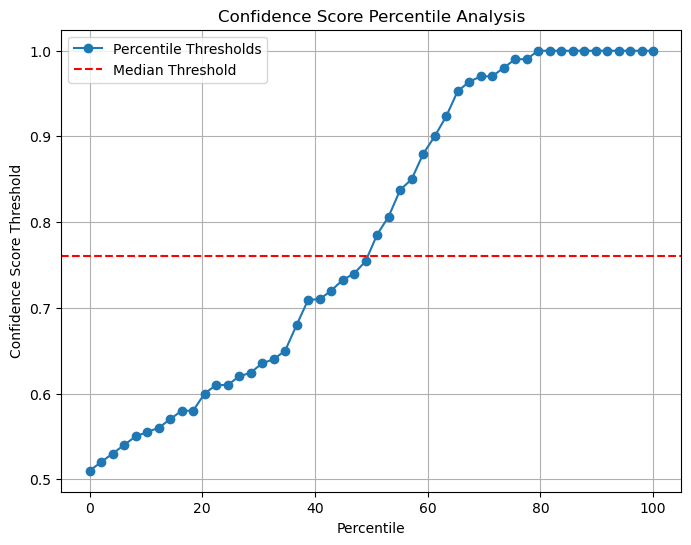

Best Confidence Score Threshold (90th Percentile): 1.00


In [134]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extract confidence scores from your regression DataFrame
confidence_scores = df_regression["ConfidenceScore"].values

# Sort confidence scores
sorted_confidence = np.sort(confidence_scores)

# Define percentiles to analyze
percentiles = np.linspace(0, 100, 50)  # 50 evenly spaced percentiles
thresholds = np.percentile(sorted_confidence, percentiles)

# Plot Confidence Score Percentile Analysis
plt.figure(figsize=(8, 6))
plt.plot(percentiles, thresholds, marker='o', linestyle='-', color='C0', label="Percentile Thresholds")
plt.xlabel('Percentile')
plt.ylabel('Confidence Score Threshold')
plt.title('Confidence Score Percentile Analysis')
plt.axhline(y=np.median(sorted_confidence), color='r', linestyle='dashed', label="Median Threshold")
plt.legend()
plt.grid()
plt.show()

# Select best threshold (e.g., 90th percentile as a decision boundary)
best_threshold = np.percentile(sorted_confidence, 90)
print(f"Best Confidence Score Threshold (90th Percentile): {best_threshold:.2f}")


Best Confidence Score Threshold: 0.84


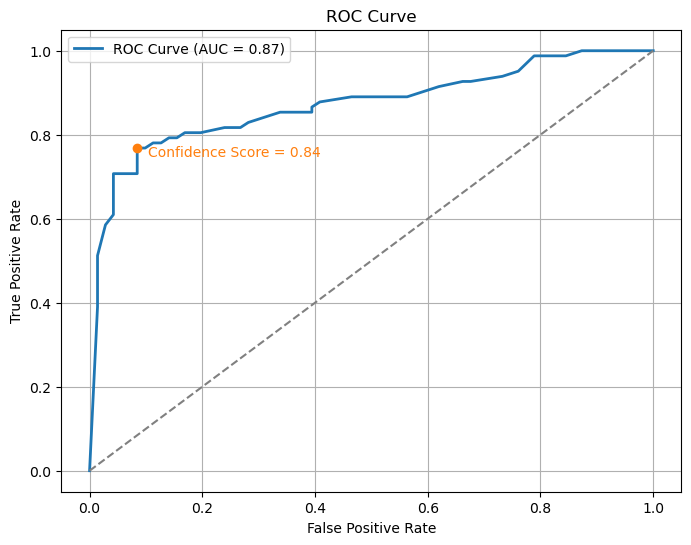

In [135]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Extract Confidence Scores & Validation Labels (1 = Correct, 0 = Incorrect)
y_true = df_regression["Validation"].values  # 1 = Correct Prediction, 0 = Incorrect Prediction
y_scores = df_regression["ConfidenceScore"].values  # Model's confidence score

# Compute ROC Curve (False Positive Rate & True Positive Rate)
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)  # Compute AUC Score

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='C0', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='dashed')  # Random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()

# Find the Best Threshold (Closest to (0,1) on ROC Curve)
best_index = np.argmax(tpr - fpr)  # Maximize TPR - FPR
best_threshold = thresholds[best_index]

# Highlight the best threshold on the graph
plt.scatter(fpr[best_index], tpr[best_index], color='C1', label=f'Best Threshold = {best_threshold:.2f}', zorder=5)
plt.text(fpr[best_index] + 0.02, tpr[best_index] - 0.02, 
         f"Confidence Score = {best_threshold:.2f}", 
         color='C1', fontsize=10)

print(f"Best Confidence Score Threshold: {best_threshold:.2f}")

plt.show()


In [136]:
df_regression

,File,SegmentFile,StartSecond,EndSecond,StartRecordingTimestamp,StartAnnotationTimestamp,EndAnnotationTimestamp,Specie,Validation,Suggested Specie,ConfidenceScore,Validation Value,LogitScore
0,channelA_2024-05-27_21-43-19.WAV,channelA_2024-05-27_21-43-19_48kHz_286_293_0.5...,286.0,293.0,2024-05-27 21:43:19,2024-05-27 21:48:05,2024-05-27 21:48:12,Whistle,1,Whistle,0.5600,Whistle,0.241
1,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_0_5_0.98.WAV,0.0,5.0,2024-05-27 21:48:19,2024-05-27 21:48:19,2024-05-27 21:48:24,Whistle,1,Whistle,0.9800,Whistle,3.892
2,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_103_110_0.9...,103.0,110.0,2024-05-27 21:48:19,2024-05-27 21:50:02,2024-05-27 21:50:09,Whistle,1,Whistle,0.9100,Whistle,2.314
3,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_106_113_0.9...,106.0,113.0,2024-05-27 21:48:19,2024-05-27 21:50:05,2024-05-27 21:50:12,Whistle,1,Whistle,0.9800,Whistle,3.892
4,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_109_116_1.0...,109.0,116.0,2024-05-27 21:48:19,2024-05-27 21:50:08,2024-05-27 21:50:15,Whistle,1,Whistle,0.9999,Whistle,9.210
...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,channelA_2024-06-12_16-00-33.WAV,channelA_2024-06-12_16-00-33_48kHz_106_113_0.6...,106.0,113.0,2024-06-12 16:00:33,2024-06-12 16:02:19,2024-06-12 16:02:26,Whistle,0,Ferry_FastFerry,0.6200,Other,0.490
151,channelA_2024-06-12_16-15-33.WAV,channelA_2024-06-12_16-15-33_48kHz_25_32_0.58.WAV,25.0,32.0,2024-06-12 16:15:33,2024-06-12 16:15:58,2024-06-12 16:16:05,Whistle,0,Ferry_FastFerry,0.5800,Other,0.323
152,channelA_2024-06-12_16-15-33.WAV,channelA_2024-06-12_16-15-33_48kHz_34_41_0.61.WAV,34.0,41.0,2024-06-12 16:15:33,2024-06-12 16:16:07,2024-06-12 16:16:14,Whistle,0,Ferry_FastFerry,0.6100,Other,0.447
153,channelA_2024-06-12_16-15-33.WAV,channelA_2024-06-12_16-15-33_48kHz_40_47_0.61.WAV,40.0,47.0,2024-06-12 16:15:33,2024-06-12 16:16:13,2024-06-12 16:16:20,Whistle,0,Ferry_FastFerry,0.6100,Other,0.447


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.metrics import precision_recall_curve, auc

# # Extract Confidence Scores & Validation Labels (1 = Correct, 0 = Incorrect)
# y_true = df_regression["Validation"].values  # 1 = Correct Prediction, 0 = Incorrect Prediction
# y_scores = df_regression["ConfidenceScore"].values  # Model's confidence score

# # Compute Precision and Recall
# precision, recall, thresholds = precision_recall_curve(y_true, y_scores)

# # Plot Precision-Recall Curve
# plt.figure(figsize=(8, 6))
# plt.plot(recall, precision, color='C0', lw=2, label='Precision-Recall Curve')

# # Highlight the best threshold
# best_threshold_index = np.argmax(precision + recall)
# best_threshold = thresholds[best_threshold_index]
# plt.scatter(recall[best_threshold_index], precision[best_threshold_index], color='C1', label=f'Best Threshold = {best_threshold:.2f}', zorder=5)
# plt.text(recall[best_threshold_index] + 0.02, precision[best_threshold_index] - 0.02, 
#          f"Confidence\nScore = {best_threshold:.2f}", color='C1', fontsize=10)

# # Labels and Title
# plt.xlabel('Recall')
# plt.ylabel('Precision')
# plt.title('Precision-Recall Curve')
# plt.legend()
# plt.grid(True)
# plt.show()

# # Calculate AUC for Precision-Recall Curve
# pr_auc = auc(recall, precision)
# print(f"Precision-Recall AUC: {pr_auc:.2f}")
# print(f"Best Confidence Score Threshold for Precision-Recall Curve: {best_threshold:.2f}")

NameError: name 'df_regression' is not defined

In [137]:
import numpy as np
from sklearn.metrics import precision_recall_curve

# Calculate Precision and Recall
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)

# Find the index where the sum of Precision and Recall is maximized
best_threshold_index = np.argmax(precision + recall)

# Get the best threshold value
best_threshold = thresholds[best_threshold_index]

# Print out the best threshold and corresponding precision and recall values
print(f"Best Confidence Score Threshold (Max Precision + Recall): {best_threshold:.2f}")
print(f"Precision at Threshold: {precision[best_threshold_index]:.2f}")
print(f"Recall at Threshold: {recall[best_threshold_index]:.2f}")

Best Confidence Score Threshold (Max Precision + Recall): 0.84
Precision at Threshold: 0.91
Recall at Threshold: 0.77


In [147]:
df_regression

,File,SegmentFile,StartSecond,EndSecond,StartRecordingTimestamp,StartAnnotationTimestamp,EndAnnotationTimestamp,Specie,Validation,Suggested Specie,ConfidenceScore,Validation Value,LogitScore
0,channelA_2024-05-27_21-43-19.WAV,channelA_2024-05-27_21-43-19_48kHz_286_293_0.5...,286.0,293.0,2024-05-27 21:43:19,2024-05-27 21:48:05,2024-05-27 21:48:12,Whistle,1,Whistle,0.5600,Whistle,0.241
1,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_0_5_0.98.WAV,0.0,5.0,2024-05-27 21:48:19,2024-05-27 21:48:19,2024-05-27 21:48:24,Whistle,1,Whistle,0.9800,Whistle,3.892
2,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_103_110_0.9...,103.0,110.0,2024-05-27 21:48:19,2024-05-27 21:50:02,2024-05-27 21:50:09,Whistle,1,Whistle,0.9100,Whistle,2.314
3,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_106_113_0.9...,106.0,113.0,2024-05-27 21:48:19,2024-05-27 21:50:05,2024-05-27 21:50:12,Whistle,1,Whistle,0.9800,Whistle,3.892
4,channelA_2024-05-27_21-48-19.WAV,channelA_2024-05-27_21-48-19_48kHz_109_116_1.0...,109.0,116.0,2024-05-27 21:48:19,2024-05-27 21:50:08,2024-05-27 21:50:15,Whistle,1,Whistle,0.9999,Whistle,9.210
...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,channelA_2024-06-12_16-00-33.WAV,channelA_2024-06-12_16-00-33_48kHz_106_113_0.6...,106.0,113.0,2024-06-12 16:00:33,2024-06-12 16:02:19,2024-06-12 16:02:26,Whistle,0,Ferry_FastFerry,0.6200,Other,0.490
151,channelA_2024-06-12_16-15-33.WAV,channelA_2024-06-12_16-15-33_48kHz_25_32_0.58.WAV,25.0,32.0,2024-06-12 16:15:33,2024-06-12 16:15:58,2024-06-12 16:16:05,Whistle,0,Ferry_FastFerry,0.5800,Other,0.323
152,channelA_2024-06-12_16-15-33.WAV,channelA_2024-06-12_16-15-33_48kHz_34_41_0.61.WAV,34.0,41.0,2024-06-12 16:15:33,2024-06-12 16:16:07,2024-06-12 16:16:14,Whistle,0,Ferry_FastFerry,0.6100,Other,0.447
153,channelA_2024-06-12_16-15-33.WAV,channelA_2024-06-12_16-15-33_48kHz_40_47_0.61.WAV,40.0,47.0,2024-06-12 16:15:33,2024-06-12 16:16:13,2024-06-12 16:16:20,Whistle,0,Ferry_FastFerry,0.6100,Other,0.447


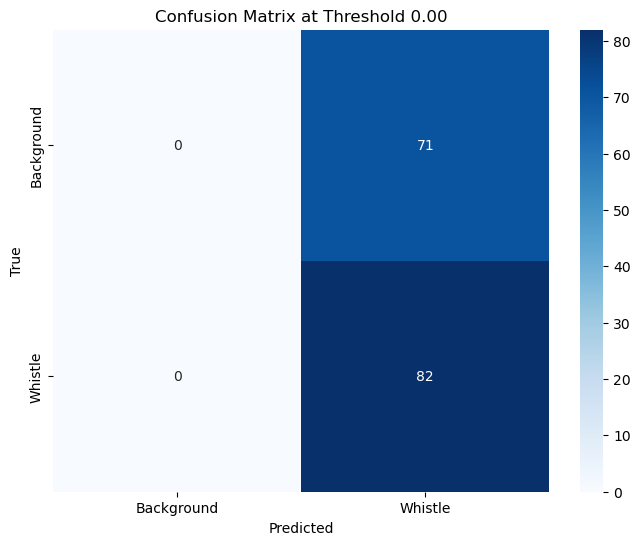

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        71
           1       0.54      1.00      0.70        82

    accuracy                           0.54       153
   macro avg       0.27      0.50      0.35       153
weighted avg       0.29      0.54      0.37       153



/home/gruncrow/anaconda3/envs/DataAnalysis/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/gruncrow/anaconda3/envs/DataAnalysis/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/gruncrow/anaconda3/envs/DataAnalysis/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

In [153]:
# Calculate all metrics for confidence score threshold 0.84
from sklearn.metrics import confusion_matrix, classification_report
# Set the threshold
threshold = 0

# Convert y_true to binary: 1 for 'Whistle', 0 for all others
y_true = (df_regression["Validation Value"] == "Whistle").astype(int).values
y_scores = df_regression["ConfidenceScore"].values  # Model's confidence score
# Predict labels based on the threshold
predicted_labels = (y_scores >= threshold).astype(int)
# Calculate confusion matrix
cm = confusion_matrix(y_true, predicted_labels)

# Plot confusion matrix
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Background', 'Whistle'], yticklabels=['Background', 'Whistle'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix at Threshold {threshold:.2f}')
plt.show()

# Calculate classification report
print(classification_report(y_true, predicted_labels))

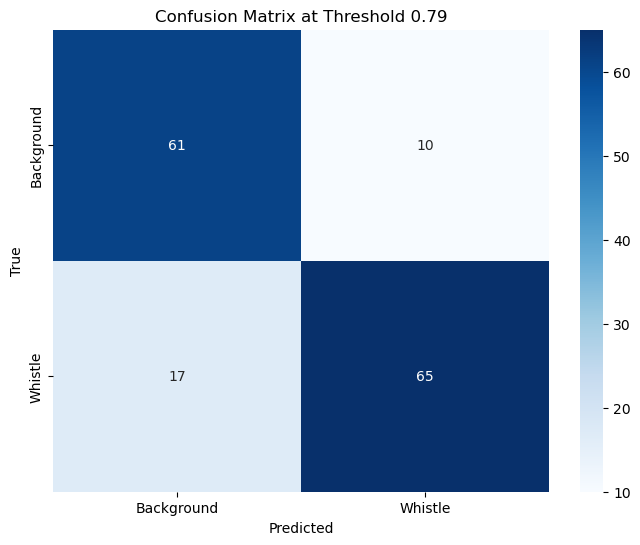

              precision    recall  f1-score   support

           0       0.78      0.86      0.82        71
           1       0.87      0.79      0.83        82

    accuracy                           0.82       153
   macro avg       0.82      0.83      0.82       153
weighted avg       0.83      0.82      0.82       153



In [154]:
# Calculate all metrics for confidence score threshold 0.84
from sklearn.metrics import confusion_matrix, classification_report
# Set the threshold
threshold = 0.79

# Convert y_true to binary: 1 for 'Whistle', 0 for all others
y_true = (df_regression["Validation Value"] == "Whistle").astype(int).values
y_scores = df_regression["ConfidenceScore"].values  # Model's confidence score
# Predict labels based on the threshold
predicted_labels = (y_scores >= threshold).astype(int)
# Calculate confusion matrix
cm = confusion_matrix(y_true, predicted_labels)

# Plot confusion matrix
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Background', 'Whistle'], yticklabels=['Background', 'Whistle'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix at Threshold {threshold:.2f}')
plt.show()

# Calculate classification report
print(classification_report(y_true, predicted_labels))

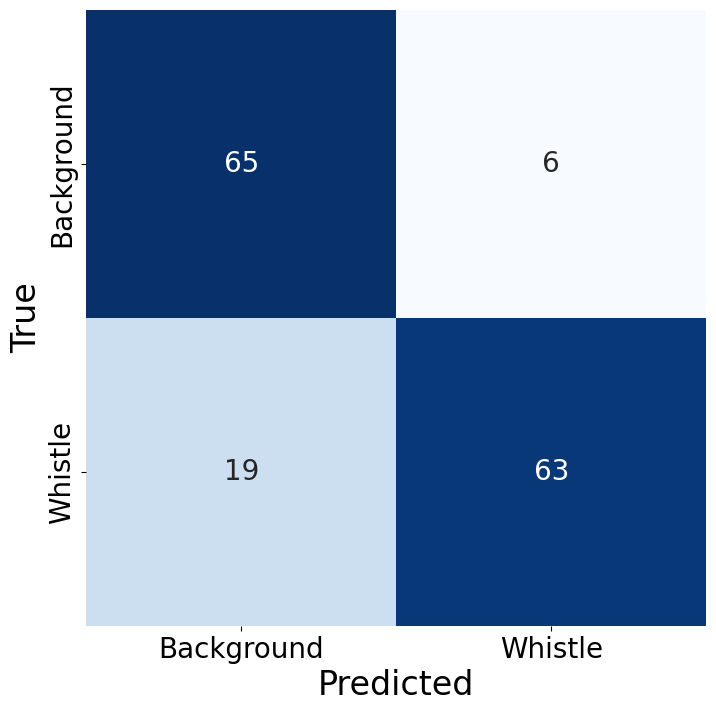

              precision    recall  f1-score   support

           0       0.77      0.92      0.84        71
           1       0.91      0.77      0.83        82

    accuracy                           0.84       153
   macro avg       0.84      0.84      0.84       153
weighted avg       0.85      0.84      0.84       153



In [165]:
# Calculate all metrics for confidence score threshold 0.84
from sklearn.metrics import confusion_matrix, classification_report
# Set the threshold
threshold = 0.84

# Convert y_true to binary: 1 for 'Whistle', 0 for all others
y_true = (df_regression["Validation Value"] == "Whistle").astype(int).values
y_scores = df_regression["ConfidenceScore"].values  # Model's confidence score
# Predict labels based on the threshold
predicted_labels = (y_scores >= threshold).astype(int)
# Calculate confusion matrix
cm = confusion_matrix(y_true, predicted_labels)

# Plot confusion matrix
import seaborn as sns
plt.figure(figsize=(8, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Background', 'Whistle'],
    yticklabels=['Background', 'Whistle'],
    cbar=False,
    annot_kws={"size": 20}  # Make numbers bigger
)
plt.xlabel('Predicted', fontsize=24)
plt.ylabel('True', fontsize=24)
# plt.title(f'Confusion Matrix at Threshold {threshold:.2f}', fontsize=28)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.savefig("../../../Figures/Deployment1_confusion_matrix_threshold_{:.2f}.pdf".format(threshold))
plt.show()

# Calculate classification report
print(classification_report(y_true, predicted_labels))